In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan
import matplotlib.pyplot as plt

from rossby_utils import bootstrap_utils as boot
from rossby_utils import plothisto_utils as histo
from rossby_utils import modeleval_utils as modeval

### Reading in the data

In [9]:
era5 = xr.open_dataset(
    "/glade/campaign/cgd/cas/islas/python_savs/rossbypalooza26/processing/ERA5/ERA5_monthly_slp_1993_2025.nc").slp

sys = [ '600','601','602','603','604' ]
count=0
model=[]
for isys in sys:
    dat = xr.open_dataset("/glade/campaign/cgd/cas/islas/DATASETS/CDS/seasonal/UKMO/nc/slp/"+isys+"/hindcast_anoms_ALLM_slp.nc")
    dat = dat.rename({'member':'M'})
    dat['member'] = np.arange(count, count + dat.M.size,1)
    count = count + dat.M.size
    model.append(dat.slp)
model = xr.concat(model, dim='M')

### select only years 1993-2016

In [10]:
era5 = era5.sel(year=slice(1993,2016))
model = model.sel(year=slice(1993,2016))

### Calculate the station based NAO index

In [11]:
### Remove the lead dependent climatology
era5_anoms = era5 - era5.mean('year')
model_anoms = model - model.mean('year')

### Normalize each month by its standard deviation
era5_norm = era5_anoms / era5_anoms.std('year')
model_norm = model_anoms / model_anoms.std('year')

### 
# Iceland lon and lat 
lon_ice = 360 - 21.9 ; lat_ice = 64.1
# Azores lon and lat
lon_az = 360 - 28 ; lat_az = 39.5

era5_nao = era5_norm.sel(lon=lon_az, lat=lat_az, method='nearest') - era5_norm.sel(lon=lon_ice, lat=lat_ice, method='nearest')
model_nao = model_norm.sel(lon=lon_az, lat=lat_az, method='nearest') - model_norm.sel(lon=lon_ice, lat=lat_ice, method='nearest')

era5_nao_djf = era5_nao.isel(lead=slice(1,4)).mean('lead')
model_nao_djf = model_nao.isel(lead=slice(1,4)).mean('lead')

era5_nao_djf = era5_nao_djf.compute()
model_nao_djf = model_nao_djf.compute()

### Two different ways to sample.  Method A = only sample the single member of the model and compute the RPC using the original model ensemble in the same way as observations.  Method B = incorporate uncertainty in the Eade denomenator by also sampling N members from the N available with replacement.  Do this for both the model and the observations

In [25]:
boot_nao_1mem = []
boot_nao_Nmem = []
for iyear in np.arange(0,model_nao_djf.year.size,1): # loop over years

    # bootstrap 1 member (equivalent to observations)
    boot_temp_1mem = boot.bootgen(model_nao_djf.isel(year=iyear), nsamples=1, seed=iyear, nboots=1000).isel(isample=0)

    # bootstrap N members with replacement to explore uncertainty in the denomenator
    boot_temp_Nmem = boot.bootgen(model_nao_djf.isel(year=iyear), nsamples = model.M.size, seed = iyear + 100, nboots=1000)

    boot_nao_1mem.append(boot_temp_1mem)
    boot_nao_Nmem.append(boot_temp_Nmem)

# Concatenate the list of arrays to give an array of the form (year, nboots)
boot_nao_1mem = xr.concat(boot_nao_1mem, dim=model_nao_djf.year)
boot_nao_Nmem = xr.concat(boot_nao_Nmem, dim=model_nao_djf.year)

### Compute the RPC's

### Method A, only considering the sampling uncertainty in the numerator, keeping the model ensemble used in the denomenator the same

In [27]:
rpc_model_a, num, denom = modeval.compute_rpc_eade(model_nao_djf, model_nao_djf.mean('M'), boot_nao_1mem, timeaxis='year')
rpc_obs_a, num, denom = modeval.compute_rpc_eade(model_nao_djf, model_nao_djf.mean('M'), era5_nao_djf, timeaxis='year')

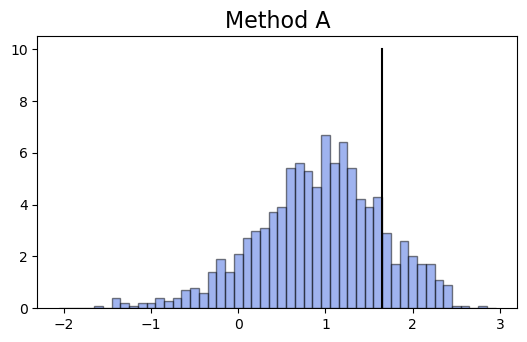

In [29]:
fig = plt.figure(figsize=(16,16))

ax = histo.plothisto(fig, rpc_model_a,np.arange(-2,3.1,0.1),0.02,0.32,0.8,0.97, 
                     percent=True, title="Method A", color='royalblue', alpha=0.5)
ax.plot([rpc_obs_a, rpc_obs_a],[0,10], color='black', label='ERA5')

### Method B, also considering the sampling uncertainty in the denomenator

In [31]:
boot_nao_Nmem = boot_nao_Nmem.rename({'isample':'M'})

In [32]:
rpc_model_b, num, denom = modeval.compute_rpc_eade(boot_nao_Nmem, boot_nao_Nmem.mean('M'), boot_nao_1mem, timeaxis='year')
rpc_obs_b, num, denom = modeval.compute_rpc_eade(boot_nao_Nmem, boot_nao_Nmem.mean('M'), era5_nao_djf.broadcast_like(boot_nao_1mem), timeaxis='year')

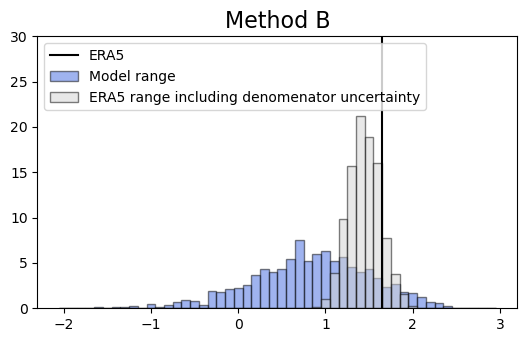

In [39]:
fig = plt.figure(figsize=(16,16))

ax = histo.plothisto(fig, rpc_model_b,np.arange(-2,3.1,0.1),0.02,0.32,0.8,0.97, 
                     percent=True, title="Method B", color='royalblue', alpha=0.5, label='Model range')
ax.set_ylim(0,30)
ax = histo.oplothisto(ax, rpc_obs_b, np.arange(-2,3.1,0.1) ,percent=True, color='lightgray', alpha=0.5, label='ERA5 range including denomenator uncertainty')
ax.plot([rpc_obs_a, rpc_obs_a],[0,30], color='black', label='ERA5')
ax.legend(loc='upper left')